In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import astropy
import astropy.cosmology
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

import matplotlib
from matplotlib import cm
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib import pyplot as plt

import sys
sys.path.insert(0,'../code')
import utils
import correlations
import maps

%load_ext autoreload
%autoreload 2

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18

matplotlib.rc('text', usetex=False)

# Needed settings copied from 2023-10-08_paper_figures.ipynb notebook

Names

In [3]:
name_catalog = '\emph{{Gaia}}-\emph{{unWISE}} Quasar Catalog'
abbrv_catalog = 'Quaia'

name_gpurer = "\emph{{Gaia}} DR3 Quasars `Purer' Sample"
abbrv_gpurer = "\emph{{Gaia}} DR3 `Purer'"

name_gall = "\emph{{Gaia}} DR3 Quasar Candidates"
abbrv_gall = "\emph{{Gaia}} DR3 Quasar Candidates"

name_sqall = "SDSS DR16Q Quasars"
abbrv_sqall = "SDSS DR16Q Quasars"

In [4]:
name_zgaia = "\emph{{Gaia}} redshift" 
abbrv_zgaia = "z_\mathrm{Gaia}"

name_zsdss = "\emph{{SDSS}} redshift" 
abbrv_zsdss = "z_\mathrm{SDSS}"

name_zspz = f"{abbrv_catalog} redshift" 
abbrv_zspz = f"z_\mathrm{{{abbrv_catalog}}}"

Plotting variables

In [5]:
cmap_anim = utils.shiftedColorMap(matplotlib.cm.plasma_r, start=0.2, midpoint=0.6, stop=1.0)
cmap_map = 'plasma'
cmap_blues = utils.shiftedColorMap(matplotlib.cm.Blues, start=0.2, midpoint=0.6, stop=1.0)
cmap_hist = utils.shiftedColorMap(matplotlib.cm.inferno_r, start=0.1, midpoint=0.55, stop=1.0)

color_gaia = 'purple'

Other prelims

In [6]:
G_hi = 20.5
G_lo = 20.0

## Redshift analysis vs SDSS

In [7]:
redshift_estimator_name = 'kNN'
## BEWARE! older versions of this file are wrong. latest is from Oct 2, 2023. 
# (an old version from april will give wrong results!)
save_tag_model = f'_K27_std'
fn_spz_labeled = f'../data/redshift_estimates/redshifts_spz_labeled_{redshift_estimator_name}{save_tag_model}.fits'
tab_spz_labeled = utils.load_table(fn_spz_labeled)
print(f"N = {len(tab_spz_labeled)}")
print(tab_spz_labeled.columns)

N = 243206
<TableColumns names=('source_id','z_sdss','phot_g_mean_mag','redshift_qsoc','rand_ints','redshift_spz_raw','redshift_spz_err','redshift_spz')>


In [8]:
rand_ints_labeled = tab_spz_labeled['rand_ints']
i_train, i_valid, i_test = utils.split_train_val_test(rand_ints_labeled,
                                 frac_train=0.7, frac_val=0.15, frac_test=0.15)

In [9]:
idx_Glo_test = tab_spz_labeled['phot_g_mean_mag'][i_test] < G_lo

In [10]:
idx_Ghi_test = tab_spz_labeled['phot_g_mean_mag'][i_test] < G_hi

### Redshift estimates vs SDSS accuracy

In [11]:
z_sdss_test = tab_spz_labeled['z_sdss'][i_test]
z_spzraw_test = tab_spz_labeled['redshift_spz_raw'][i_test]
z_spz_test = tab_spz_labeled['redshift_spz'][i_test]
z_gaia_test = tab_spz_labeled['redshift_qsoc'][i_test]

In [12]:
dz_spzraw_test = (z_spzraw_test - z_sdss_test)/(1+z_sdss_test)
dz_spz_test = (z_spz_test - z_sdss_test)/(1+z_sdss_test)
dz_gaia_test = (z_gaia_test - z_sdss_test)/(1+z_sdss_test)

In [13]:
z_bins = np.linspace(0, np.max(z_gaia_test), 200)

# Reproduction of redshift outlier fraction plot from 2023-10-08_paper_figures.ipynb notebook

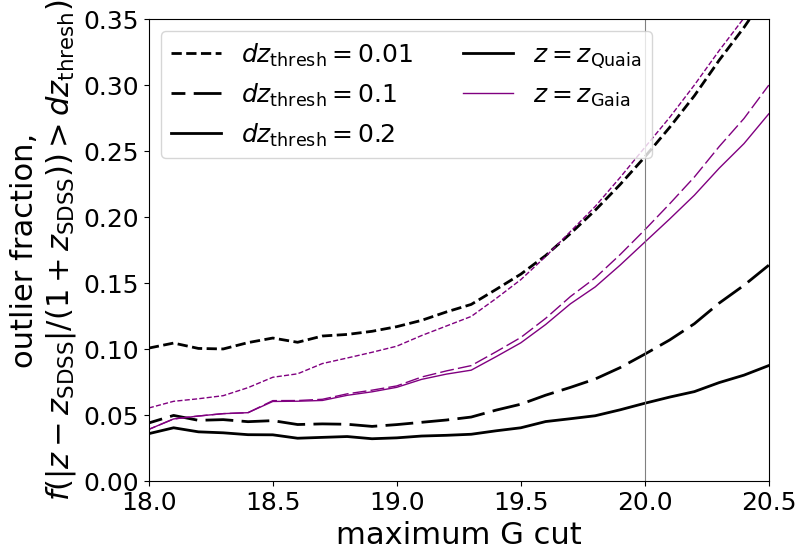

In [14]:
plt.figure(figsize=(8,6))
ax = plt.gca()

G_arr = tab_spz_labeled['phot_g_mean_mag'][i_test]
G_maxs = np.arange(18.0, 20.501, 0.1)

dz_threshs = [0.01, 0.1, 0.2]
alphas = [0.4, 0.6, 0.8, 1]
lss = ['--', (5, (10,3)), '-']
for iz, dz_thresh in enumerate(dz_threshs):
    n_insample = np.empty(len(G_maxs), dtype=int)
    f_outliers_spz = np.empty(len(G_maxs))
    f_outliers_gaia = np.empty(len(G_maxs))

    for i in range(len(G_maxs)):
        i_insample = G_arr < G_maxs[i]
        n_insample[i] = np.sum(i_insample)
        
        f_outliers_spz[i] = np.sum(np.abs(dz_spz_test[i_insample]) > dz_thresh) / n_insample[i]
        f_outliers_gaia[i] = np.sum(np.abs(dz_gaia_test[i_insample]) > dz_thresh) / n_insample[i]
        
    plt.plot(G_maxs, f_outliers_spz, color='k', alpha=1, ls=lss[iz], lw=2, label=fr'$dz_\mathrm{{thresh}}={dz_thresh}$')
    plt.plot(G_maxs, f_outliers_gaia, color=color_gaia, alpha=1, ls=lss[iz], lw=1)

plt.xlabel("maximum G cut")
plt.ylabel('outlier fraction,\n' + rf'$f(|z-{abbrv_zsdss}|/(1+{abbrv_zsdss}))>dz_\mathrm{{thresh}})$')
plt.ylim(0, 0.35)
plt.xlim(np.min(G_maxs), np.max(G_maxs))


handles, labels = ax.get_legend_handles_labels()
line_spz = Line2D([], [], color='k', lw=2)
line_gaia = Line2D([], [], color=color_gaia, lw=1)
handles.extend([line_spz, line_gaia])
labels.extend([f'$z={abbrv_zspz}$', f'$z={abbrv_zgaia}$'])

plt.legend(handles, labels, ncol=2)

plt.axvline(20.0, color='grey', lw=0.8)

# fn = f'{plot_dir}/redshift_outliers_vs_Gmax.png'
# if save:
#     plt.savefig(fn, bbox_inches='tight')

# Recheck with updated Quaia catalog & SDSS files

In [15]:
fn_quaia = '../data/quaia_G20.5.fits'
tab_quaia = utils.load_table(fn_quaia)
print(len(tab_quaia))

1295502


In [16]:
tab_squasars = utils.load_table(f'../data/quasars_sdss_xgaia_xunwise_good_nodup.fits')
print(f"Number of SDSS quasars: {len(tab_squasars)}")
print(tab_squasars.columns)

Number of SDSS quasars: 379698
<TableColumns names=('ra','dec','source_id','ra_sdss','dec_sdss','objid','z_sdss','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','phot_bp_n_obs','phot_rp_n_obs','dec_unwise','mag_w1_vg','mag_w2_vg','ra_unwise','unwise_objid','dist_arcsec')>


In [17]:
fn_gaia = '../data/gaia_candidates.fits.gz'
tab_gaia = utils.load_table(fn_gaia)
print(len(tab_gaia))
print(tab_gaia.columns)

6649162
<TableColumns names=('source_id','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','phot_g_n_obs','phot_bp_n_obs','phot_rp_n_obs','redshift_qsoc','redshift_qsoc_lower','redshift_qsoc_upper','zscore_qsoc','flags_qsoc','pmra','pmra_error','pmdec','pmdec_error','parallax','parallax_error')>


In [18]:
cols_right = [c for c in tab_squasars.colnames if c not in tab_quaia.colnames or c == 'source_id']
tab_qs = join(tab_quaia, tab_squasars[cols_right], keys='source_id', join_type='inner')
print(len(tab_qs))
print(tab_qs.columns)


221757
<TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error','ra_sdss','dec_sdss','objid','z_sdss','phot_bp_n_obs','phot_rp_n_obs','dec_unwise','ra_unwise','dist_arcsec')>


In [19]:
tab_qsg = join(tab_qs, tab_gaia[['source_id', 'redshift_qsoc']], keys='source_id', join_type='inner')
print(len(tab_qs))

221757


In [20]:
tab_qsg.columns

<TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error','ra_sdss','dec_sdss','objid','z_sdss','phot_bp_n_obs','phot_rp_n_obs','dec_unwise','ra_unwise','dist_arcsec','redshift_qsoc')>

In [21]:
z_quaia = tab_qsg['redshift_quaia']
z_sdss = tab_qsg['z_sdss']
z_gaia = tab_qsg['redshift_qsoc']
dz_quaia = (z_quaia - z_sdss)/(1+z_sdss)
dz_gaia = (z_gaia - z_sdss)/(1+z_sdss)

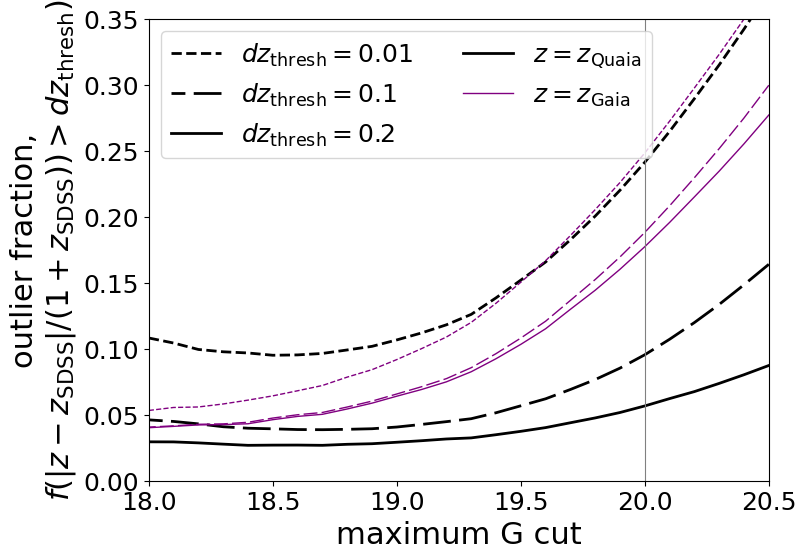

In [22]:
plt.figure(figsize=(8,6))
ax = plt.gca()

#G_arr = tab_spz_labeled['phot_g_mean_mag'][i_test]
G_arr = tab_qs['phot_g_mean_mag']
G_maxs = np.arange(18.0, 20.501, 0.1)

dz_threshs = [0.01, 0.1, 0.2]
alphas = [0.4, 0.6, 0.8, 1]
lss = ['--', (5, (10,3)), '-']
for iz, dz_thresh in enumerate(dz_threshs):
    n_insample = np.empty(len(G_maxs), dtype=int)
    f_outliers_spz = np.empty(len(G_maxs))
    f_outliers_gaia = np.empty(len(G_maxs))

    for i in range(len(G_maxs)):
        i_insample = G_arr < G_maxs[i]
        n_insample[i] = np.sum(i_insample)
        
        f_outliers_spz[i] = np.sum(np.abs(dz_quaia[i_insample]) > dz_thresh) / n_insample[i]
        f_outliers_gaia[i] = np.sum(np.abs(dz_gaia[i_insample]) > dz_thresh) / n_insample[i]
        
    plt.plot(G_maxs, f_outliers_spz, color='k', alpha=1, ls=lss[iz], lw=2, label=fr'$dz_\mathrm{{thresh}}={dz_thresh}$')
    plt.plot(G_maxs, f_outliers_gaia, color=color_gaia, alpha=1, ls=lss[iz], lw=1)

plt.xlabel("maximum G cut")
plt.ylabel('outlier fraction,\n' + rf'$f(|z-{abbrv_zsdss}|/(1+{abbrv_zsdss}))>dz_\mathrm{{thresh}})$')
plt.ylim(0, 0.35)
plt.xlim(np.min(G_maxs), np.max(G_maxs))


handles, labels = ax.get_legend_handles_labels()
line_spz = Line2D([], [], color='k', lw=2)
line_gaia = Line2D([], [], color=color_gaia, lw=1)
handles.extend([line_spz, line_gaia])
labels.extend([f'$z={abbrv_zspz}$', f'$z={abbrv_zgaia}$'])

plt.legend(handles, labels, ncol=2)

plt.axvline(20.0, color='grey', lw=0.8)

# fn = f'{plot_dir}/redshift_outliers_vs_Gmax.png'
# if save:
#     plt.savefig(fn, bbox_inches='tight')